In [1]:
! pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [5]:
! pip install pandas matplotlib fuzzywuzzy python-Levenshtein langdetect


Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     -------------------------------------- 981.5/981.5 kB 7.7 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993251 sha256=584305d7b26f5a538d69520cc39df4c9b4de5ec751d247c9c2707fcee42689ff
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\c1\67\88\e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
import pandas as pd
import hashlib
import re
import numpy as np

# Load both datasets
df_freelancer = pd.read_csv(r"C:/Users/USER/OneDrive/Desktop/freelancer_cleaned.csv")
df_naukri = pd.read_csv(r"C:/Users/USER/OneDrive/Desktop/naukri_posts_cleaned.csv")

# Remove duplicates
df_freelancer = df_freelancer.drop_duplicates(subset='hash_key_value')

# Generate hash for Naukri
def generate_hash(row):
    unique_str = (str(row['job_title']) + str(row['job_description']) +
                  str(row['company_name']) + str(row['job_tags']) +
                  str(row['search_key']))
    return hashlib.sha256(unique_str.encode('utf-8')).hexdigest()

df_naukri['hash_key_value'] = df_naukri.apply(generate_hash, axis=1)
df_naukri = df_naukri.drop_duplicates(subset='hash_key_value')

# Exchange rate
usd_to_inr = 83


# Clean Naukri Salary

def clean_and_convert_salary_to_usd(sal):
    if pd.isna(sal):
        return np.nan
    sal = str(sal).lower()
    if any(x in sal for x in ['not disclosed', 'unpaid', 'no fixed duration']):
        return np.nan
    # Remove special characters
    sal = re.sub(r'[^\d\-–]', '', sal)
    if '-' in sal or '–' in sal:
        parts = re.split(r'[-–]', sal)
        try:
            low = float(parts[0].strip())
        except:
            return np.nan
    else:
        try:
            low = float(sal)
        except:
            return np.nan
    # Convert LPA to INR, then to USD
    inr = low * 100000
    usd = inr / usd_to_inr
    return round(usd, 2)

df_naukri['salary_usd'] = df_naukri['salary'].apply(clean_and_convert_salary_to_usd)


# Clean Freelancer bit_amount

def clean_and_extract_bit_amount_usd(bid):
    if pd.isna(bid):
        return np.nan
    bid = str(bid).lower()
    if '/hr' in bid or 'hour' in bid:
        return np.nan
    bid = re.sub(r'[^\d\-–]', '', bid)
    if '-' in bid or '–' in bid:
        parts = re.split(r'[-–]', bid)
        try:
            low = float(parts[0].strip())
        except:
            return np.nan
    else:
        try:
            low = float(bid)
        except:
            return np.nan
    return round(low, 2)

df_freelancer['salary_usd'] = df_freelancer['bit_amount'].apply(clean_and_extract_bit_amount_usd)


# Select common columns
common_columns = ['job_title', 'job_description', 'job_tags', 'scraped_on', 'search_key', 'hash_key_value']

df_freelancer_clean = df_freelancer[common_columns + ['salary_usd']].copy()
df_naukri_clean = df_naukri[common_columns + ['salary_usd']].copy()

df_freelancer_clean['source'] = 'freelancer'
df_naukri_clean['source'] = 'naukri'


# Combine
df_combined = pd.concat([df_freelancer_clean, df_naukri_clean], ignore_index=True)


# Remove illegal characters from text columns
def remove_illegal_chars(text):
    if isinstance(text, str):
        return re.sub(r"[\x00-\x1F\x7F]", "", text)
    return text

for col in df_combined.select_dtypes(include='object').columns:
    df_combined[col] = df_combined[col].apply(remove_illegal_chars)
    

# Remove completely empty columns
df_combined.dropna(axis=1, how='all', inplace=True)

# Save to file
output_path = r"C:/Users/USER/OneDrive/Desktop/combined_job.csv"
try:
    df_combined.to_csv(output_path, index=False, encoding='utf-8')
    print("Combined dataset saved successfully to:", output_path)
except PermissionError:
    print("Permission Denied: Close the file if open, or try another filename.")


Combined dataset saved successfully to: C:/Users/USER/OneDrive/Desktop/combined_job.csv


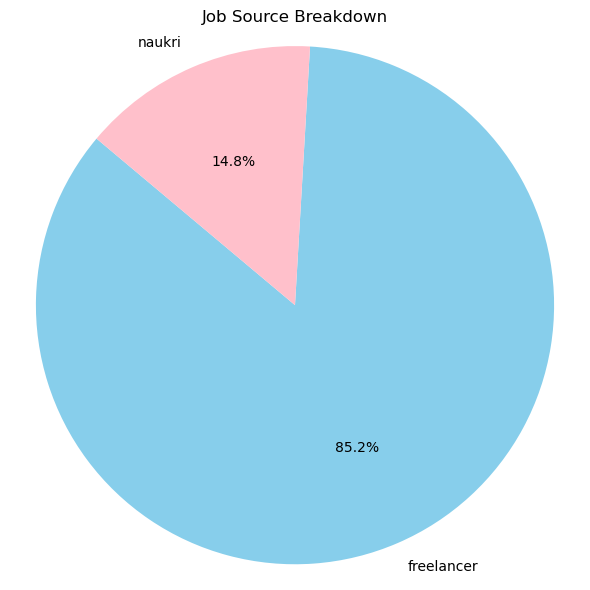

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned CSV
df = pd.read_csv(r"C:/Users/USER/OneDrive/Desktop/combined_job.csv")

# Drop completely empty rows
df.dropna(how='all', inplace=True)

# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Drop rows where 'source' is missing or empty
df = df[df['source'].notna() & (df['source'].str.strip() != '')]

# Count job postings by source
source_counts = df['source'].value_counts()
source_percent = source_counts / source_counts.sum() * 100

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(source_percent, labels=source_percent.index, autopct='%1.1f%%', startangle=140, colors=['Skyblue', 'Pink'])
plt.title('Job Source Breakdown')
plt.axis('equal') 
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import re
from fuzzywuzzy import process, fuzz
from langdetect import detect
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load CSV
df = pd.read_csv(r"C:/Users/USER/OneDrive/Desktop/combined_job.csv")

# Remove rows with missing or empty job_title or job_tags
df = df.dropna(subset=['job_title', 'job_tags'])
df = df[(df['job_title'].str.strip() != '') & (df['job_tags'].str.strip() != '')]

# Drop duplicate rows
df.drop_duplicates(inplace=True)

# Remove illegal characters from job_tags
def clean_text(text):
    text = re.sub(r"[^\w\s,;|/-]", '', str(text))  # Keep separators
    return text

df['job_tags'] = df['job_tags'].apply(clean_text)

# Split job_tags into individual tags
df['job_tags_list'] = df['job_tags'].str.lower().str.replace(r'[|;/]', ',', regex=True)
df['job_tags_list'] = df['job_tags_list'].str.split(',')

# Flatten the tags
df_exploded = df.explode('job_tags_list')
df_exploded['job_tags_list'] = df_exploded['job_tags_list'].str.strip()

# Remove empty tags
df_exploded = df_exploded[df_exploded['job_tags_list'].notna() & (df_exploded['job_tags_list'] != '')]

# Normalize similar tags using fuzzy matching
unique_tags = df_exploded['job_tags_list'].unique()
tag_map = {}

# Use fuzzy matching to cluster similar tags
for tag in unique_tags:
    match = process.extractOne(tag, tag_map.keys(), scorer=fuzz.token_sort_ratio)
    if match and match[1] > 85:
        tag_map[tag] = match[0]
    else:
        tag_map[tag] = tag

df_exploded['normalized_tag'] = df_exploded['job_tags_list'].map(tag_map)

# Detect and remove non-English job titles
def is_english(text):
    try:
        return detect(text) == 'en'
    except:
        return False

df_exploded = df_exploded[df_exploded['job_title'].apply(is_english)]

# Count frequency of each tag per source
tag_source_counts = df_exploded.groupby(['normalized_tag', 'source']).size().reset_index(name='count')

# Get top N tags (e.g., top 10)
top_tags = tag_source_counts.groupby('normalized_tag')['count'].sum().sort_values(ascending=False).head(10).index
tag_source_counts_top = tag_source_counts[tag_source_counts['normalized_tag'].isin(top_tags)]

# Define color schemes
freelancer_colors = list(mcolors.TABLEAU_COLORS.values())
naukri_colors = list(mcolors.CSS4_COLORS.values())[30:40]

color_map = {}
freelancer_i = 0
naukri_i = 0
for tag in top_tags:
    color_map[(tag, 'freelancer')] = freelancer_colors[freelancer_i % len(freelancer_colors)]
    freelancer_i += 1
    color_map[(tag, 'naukri')] = naukri_colors[naukri_i % len(naukri_colors)]
    naukri_i += 1

# Pie chart: Prepare labels and sizes
labels = []
sizes = []
colors = []

for _, row in tag_source_counts_top.iterrows():
    tag = row['normalized_tag']
    source = row['source']
    count = row['count']
    labels.append(f"{tag} ({source})")
    sizes.append(count)
    colors.append(color_map[(tag, source)])

# Plot pie chart
plt.figure(figsize=(10, 10))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Top AI Skills / Tags by Job Source')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [1]:
! pip install pandas matplotlib fuzzywuzzy python-Levenshtein langdetect


Defaulting to user installation because normal site-packages is not writeable


In [ ]:
import pandas as pd
import re
from fuzzywuzzy import process, fuzz
from langdetect import detect
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Load CSV
df = pd.read_csv(r"C:/Users/USER/OneDrive/Desktop/combined_job.csv")

# Remove missing/empty job_title and job_tags
df = df.dropna(subset=['job_title', 'job_tags', 'source'])
df = df[(df['job_title'].str.strip() != '') & (df['job_tags'].str.strip() != '')]

# Drop duplicates
df.drop_duplicates(inplace=True)

# Clean job_tags: remove special characters, normalize separators
def clean_text(text):
    text = re.sub(r"[^\w\s,;|/-]", '', str(text))  # Retain common separators
    return text

df['job_tags'] = df['job_tags'].apply(clean_text)
df['job_tags_list'] = df['job_tags'].str.lower().str.replace(r'[|;/]', ',', regex=True)
df['job_tags_list'] = df['job_tags_list'].str.split(',')

# Explode job_tags
df_exploded = df.explode('job_tags_list')
df_exploded['job_tags_list'] = df_exploded['job_tags_list'].str.strip()

# Drop empty tags
df_exploded = df_exploded[df_exploded['job_tags_list'].notna() & (df_exploded['job_tags_list'] != '')]

# Normalize tags using fuzzy matching
unique_tags = df_exploded['job_tags_list'].unique()
tag_map = {}

for tag in unique_tags:
    match = process.extractOne(tag, tag_map.keys(), scorer=fuzz.token_sort_ratio)
    if match and match[1] > 85:
        tag_map[tag] = match[0]
    else:
        tag_map[tag] = tag

df_exploded['normalized_tag'] = df_exploded['job_tags_list'].map(tag_map)

# Remove non-English job titles
def is_english(text):
    try:
        return detect(text) == 'en'
    except:
        return False

df_exploded = df_exploded[df_exploded['job_title'].apply(is_english)]

# Group by tag and count unique job_titles
tag_title_counts = df_exploded.groupby(['normalized_tag'])['job_title'].nunique().reset_index(name='unique_job_title_count')

# Get top 10 tags
top_tags = tag_title_counts.sort_values(by='unique_job_title_count', ascending=False).head(10)['normalized_tag']

# For color mapping by source, get dominant source per tag
tag_source_majority = df_exploded[df_exploded['normalized_tag'].isin(top_tags)]
source_mode_per_tag = tag_source_majority.groupby('normalized_tag')['source'].agg(lambda x: x.mode()[0]).reset_index()

# Merge counts with source info
chart_df = tag_title_counts[tag_title_counts['normalized_tag'].isin(top_tags)].merge(source_mode_per_tag, on='normalized_tag')

# Define color mapping
freelancer_shades = list(mcolors.TABLEAU_COLORS.values())[:5]
naukri_shades = list(mcolors.CSS4_COLORS.values())[30:40]

color_map = []
for i, row in chart_df.iterrows():
    if row['source'] == 'freelancer':
        color_map.append(freelancer_shades[i % len(freelancer_shades)])
    else:
        color_map.append(naukri_shades[i % len(naukri_shades)])

# Plot pie chart
plt.figure(figsize=(10, 10))
plt.pie(
    chart_df['unique_job_title_count'],
    labels=chart_df['normalized_tag'],
    autopct='%1.1f%%',
    startangle=140,
    colors=color_map
)
plt.title('Top AI Tags by Unique Job Titles\n(Source: Color-coded)')
plt.axis('equal')
plt.tight_layout()
plt.show()
